In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#importing the libraries
import pandas as pd
import numpy as np
from  matplotlib import pyplot as plt
import datetime
from collections import Counter

In [3]:
#Loding the cleaned dataset
df=pd.read_csv('/content/drive/MyDrive/Cleaned_dataset_sales.csv')


/tmp/ipykernel_19222/224732945.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/Cleaned_dataset_sales.csv')


In [4]:
#Making the copy of the dataset
df1=df.copy()
df1.shape
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185687 entries, 0 to 185686
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order_ID          185687 non-null  object 
 1   Product           185687 non-null  object 
 2   Quantity_Ordered  185687 non-null  float64
 3   Price_Each        185687 non-null  float64
 4   Order_Date        185686 non-null  object 
 5   Purchase_Address  185687 non-null  object 
dtypes: float64(2), object(4)
memory usage: 8.5+ MB


,Quantity_Ordered,Price_Each
count,185687.000000,185687.000000
mean,1.124543,184.518342
std,0.443068,332.843175
min,1.000000,2.990000
25%,1.000000,11.950000
50%,1.000000,14.950000
75%,1.000000,150.000000
max,9.000000,1700.000000


Expolatory Data Analysis

Q1. What was the best month of the sales? how much was earned that month.
   December , sales=4608295.70 usd

   Insight=sales are more in the months o fthe december resons may be festivals, chrismax, new year


In [5]:
#Creating the additional columns for sales and months
df1['Sales']=(df1['Quantity_Ordered']*df1['Price_Each'])
df1['Order_Date']=pd.to_datetime(df1['Order_Date'])
df1['Months']=df1['Order_Date'].dt.month
df1['Month_name']=df1['Order_Date'].dt.month_name()

In [6]:
grp_month=df1.groupby(['Months'])
grp_month['Sales'].value_counts()
# monthly_sales=grp_month[['Month_name','Sales'].sum().sort_values(ascending=False)
grp_month['Sales'].sum()


,Sales
Months,
1.0,1821413.16
2.0,2200078.08
3.0,2804973.35
4.0,3389217.98
5.0,3150616.23
6.0,2576280.15
7.0,2646461.32
8.0,2241083.37
9.0,2094465.69


<BarContainer object of 12 artists>

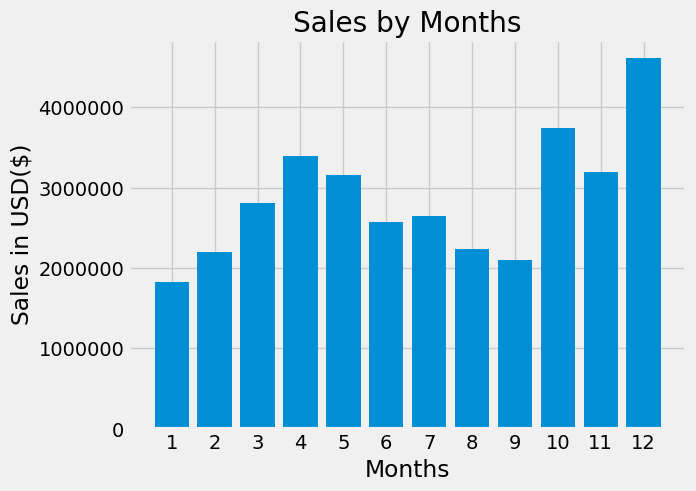

In [7]:
#ploting a bar chart
monthly_sales=grp_month['Sales'].sum()
months=range(1,13)
plt.style.use('fivethirtyeight')
plt.title('Sales by Months')
plt.xlabel('Months')
plt.ylabel('Sales in USD($)')
plt.xticks(months)
plt.ticklabel_format(style='plain', axis='y') #Remeber with this we change from scintific to normal
plt.bar(months,monthly_sales)

Q2.Which city had the highest number of sales? - San Francisco (CA)	8254743.55

 Insight=may ther is lot of population there and most of the people have good income . company should foucus on this cities so boost thre sales

In [8]:
#Adding a city columns to our dataframe
def get_city(address):
  parts = address.split(',')
  if len(parts) > 1:
    return parts[1].strip()
  return "N/A City" # Default value if city part is missing

def get_State(address):
  parts = address.split(',')
  if len(parts) > 2: # Check if there's a third part (state and zip)
    state_zip_part = parts[2].strip()
    state_parts = state_zip_part.split(' ')
    if len(state_parts) > 1: # Check if there's a state part like 'CA'
      return state_parts[0].strip()
  return "N/A State" # Default value if state part is missing

df1['City']=df1['Purchase_Address'].apply(lambda x: f"{get_city(x)} ({get_State(x)})")

In [9]:
grp_city=df1.groupby('City')
grp_city['Sales'].sum().sort_values(ascending=False)

,Sales
City,
San Francisco (CA),8254743.55
Los Angeles (CA),5448304.28
New York City (NY),4661867.14
Boston (MA),3658627.65
Atlanta (GA),2794199.07
Dallas (TX),2765373.96
Seattle (WA),2745046.02
Portland (OR),1870010.56
Austin (TX),1818044.33


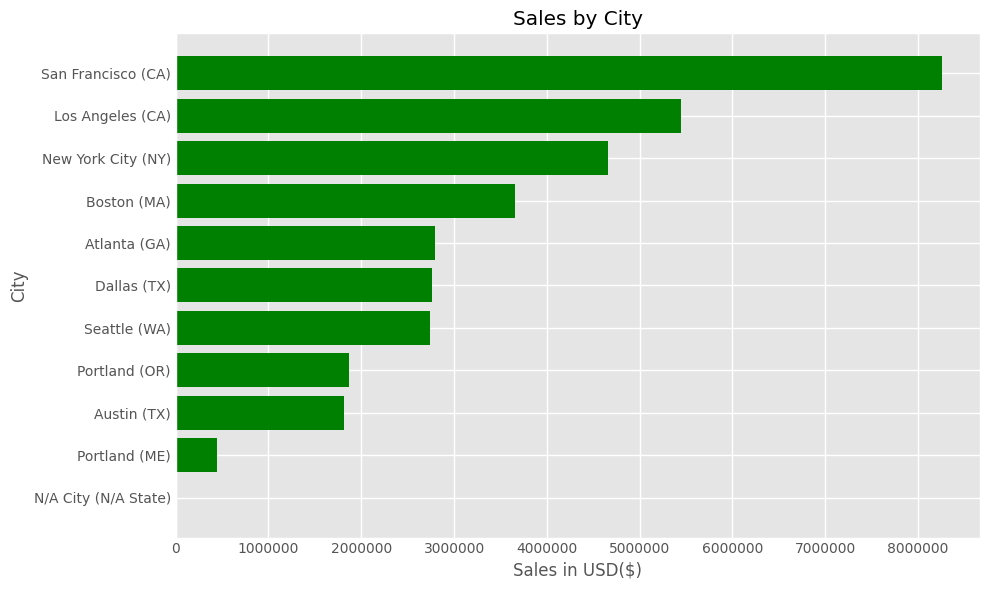

In [17]:
city_sales=grp_city['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(city_sales.index, city_sales.values,color='green')
plt.xlabel('Sales in USD($)')
plt.ylabel('City')
plt.title('Sales by City')

plt.ticklabel_format(style='plain', axis='x') #Remeber
plt.gca().invert_yaxis() # Invert y-axis to have the highest sales at the top
plt.tight_layout()
plt.show()

Q3.What time should we display advertisment to maximize likelihood of customer's buying?  - 19.0	 sales= 2411971.14

Insight=may at around 7 pm and 12 noon the sales are at its peak
may be peoples are more online and have free time , or at in lunch break ,or may fre time before or after dinner
advertisment should be digital at this time of the top products

In [11]:
df1['Hour']=df1['Order_Date'].dt.hour

In [13]:
#Grouping data by the hour
grp_hour=df1.groupby(df1['Hour'])
grp_hour['Sales'].sum()   #24 hours sales
grp_hour['Sales'].sum().sort_values(ascending=False)

,Sales
Hour,
19.0,2411971.14
12.0,2314359.85
11.0,2296619.84
20.0,2280784.36
18.0,2218374.01
13.0,2152369.98
17.0,2126553.97
14.0,2082513.70
21.0,2040790.48


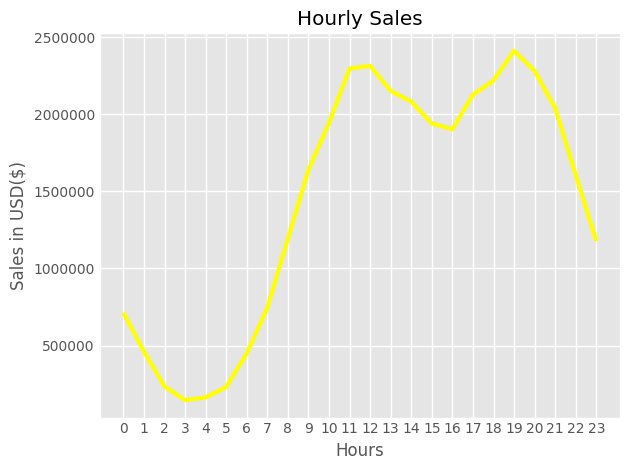

In [20]:
#Ploting a line chart

hourly_sales=grp_hour['Sales'].sum()
plt.style.use('ggplot')
plt.title('Hourly Sales')
plt.xlabel('Hours')
plt.ylabel('Sales in USD($)')
hours=range(0,24)
plt.xticks(hours)
plt.ticklabel_format(style='plain', axis='y')
plt.plot(hours,hourly_sales.values,color='yellow',linewidth=3)
plt.tight_layout()
plt.show()

Q4.What are the Products sold the most? Why do you think it sold the most (top five products)

AAA Batteries (4-pack)	30986.0
AA Batteries (4-pack)	27615.0
USB-C Charging Cable	23931.0
Lightning Charging Cable	23169.0
Wired Headphones	20524.0
 are ther top 5
 resons of top selling
 its less price greater use at many electronics things, most of the products are those which usully get used in months like non lithinon biateries

In [21]:
df1.head(10)

,Order_ID,Product,Quantity_Ordered,Price_Each,Order_Date,Purchase_Address,Sales,Months,Month_name,City,Hour
0,248151,AA Batteries (4-pack),4.0,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",15.36,9.0,September,Los Angeles (CA),14.0
1,248152,USB-C Charging Cable,2.0,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",23.90,9.0,September,Austin (TX),10.0
2,248153,USB-C Charging Cable,1.0,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",11.95,9.0,September,Los Angeles (CA),17.0
3,248154,27in FHD Monitor,1.0,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",149.99,9.0,September,Seattle (WA),7.0
4,248155,USB-C Charging Cable,1.0,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",11.95,9.0,September,Atlanta (GA),19.0
5,248156,34in Ultrawide Monitor,1.0,379.99,2019-09-13 14:59:00,"469 12th St, Los Angeles, CA 90001",379.99,9.0,September,Los Angeles (CA),14.0
6,248157,Lightning Charging Cable,1.0,14.95,2019-09-07 09:59:00,"773 Johnson St, Portland, ME 04101",14.95,9.0,September,Portland (ME),9.0
7,248158,Lightning Charging Cable,1.0,14.95,2019-09-02 14:16:00,"682 Sunset St, Los Angeles, CA 90001",14.95,9.0,September,Los Angeles (CA),14.0
8,248159,Vareebadd Phone,1.0,400.00,2019-09-06 16:45:00,"664 Wilson St, New York City, NY 10001",400.00,9.0,September,New York City (NY),16.0
9,248160,Wired Headphones,1.0,11.99,2019-09-01 22:03:00,"446 9th St, San Francisco, CA 94016",11.99,9.0,September,San Francisco (CA),22.0


In [46]:
grp_product=df1.groupby(df1['Product'])
# grp_product[['Sales','Quantity_Ordered']].sum().sort_values(by='Sales',ascending=False)
grp_product['Quantity_Ordered'].sum().sort_values(ascending=False)

,Quantity_Ordered
Product,
AAA Batteries (4-pack),30986.0
AA Batteries (4-pack),27615.0
USB-C Charging Cable,23931.0
Lightning Charging Cable,23169.0
Wired Headphones,20524.0


([<matplotlib.patches.Wedge at 0x788157580ec0>,
 [Text(0.7887781558534597, 0.7667000853322082, 'AAA Batteries (4-pack)'),
  Text(-0.6734891960756202, 0.8697196690712561, 'AA Batteries (4-pack)'),
  Text(-1.025144619385988, -0.39884647340042695, 'USB-C Charging Cable'),
  Text(-0.030234806956793384, -1.099584401693788, 'Lightning Charging Cable'),
  Text(0.9595792105034364, -0.5377803815402733, 'Wired Headphones')])

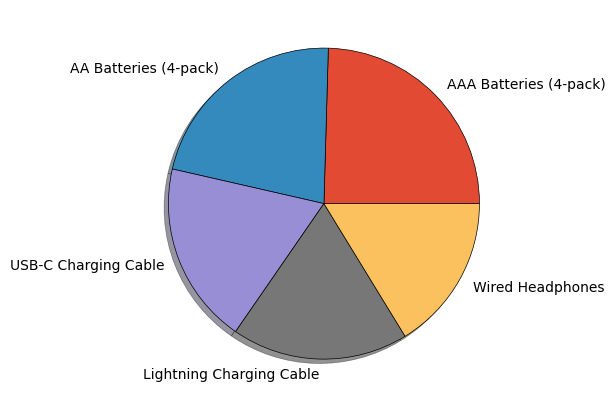

In [55]:
#Five Products on the basics of the Quantity ordered
max_order=grp_product['Quantity_Ordered'].sum().sort_values(ascending=False).head(5)
plt.pie(max_order.values,labels=max_order.index,wedgeprops={'edgecolor':'black'},shadow=True)
plt.show()

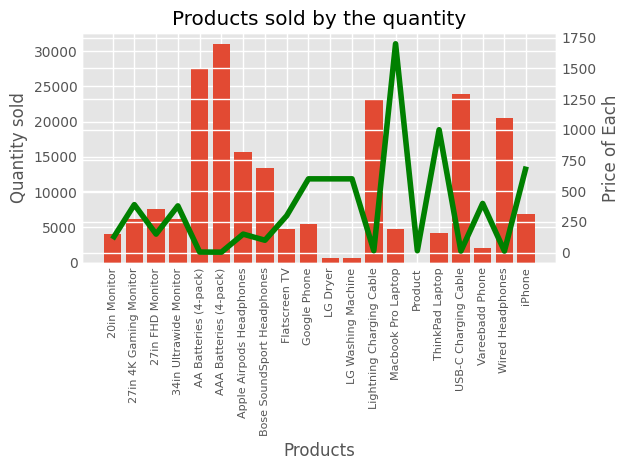

In [75]:
max_order=grp_product['Quantity_Ordered'].sum()
fig,ax1=plt.subplots()
ax2=ax1.twinx()
ax1.set_xticks(range(len(max_order.index)), max_order.index, rotation='vertical',size=8)  #it will provides numerical position for the xticks
ax1.set_title('Products sold by the quantity')
ax1.set_xlabel('Products')
ax1.set_ylabel('Quantity sold')
ax1.bar(max_order.index,max_order.values)

price=grp_product['Price_Each'].mean()
ax2.plot(price.index,price.values,color='green')
ax2.set_ylabel('Price of Each')
plt.tight_layout()
plt.show()

In [80]:
# 5 Products whose sell are at bottom

grp_product['Quantity_Ordered'].sum().sort_values(ascending=False).tail(5)

,Quantity_Ordered
Product,
20in Monitor,4126.0
Vareebadd Phone,2068.0
LG Washing Machine,666.0
LG Dryer,646.0
Product,1.0


Insight= even prices are no too high the products above are less sold ,company should focus on it .may cut extra inputs on this products and focus on the top 10

In [81]:
grp_product['Price_Each'].mean()

,Price_Each
Product,
20in Monitor,109.99
27in 4K Gaming Monitor,389.99
27in FHD Monitor,149.99
34in Ultrawide Monitor,379.99
AA Batteries (4-pack),3.84
AAA Batteries (4-pack),2.99
Apple Airpods Headphones,150.00
Bose SoundSport Headphones,99.99
Flatscreen TV,300.00
